In [ ]:
# Memastikan library yang dibutuhkan sudah siap
import os
print("Sistem Siap. Pastikan file 'Data_Kelembapan_Bayam_Brazil_1440.xlsx' sudah diupload ke menu Files di kiri.")

Sistem Siap. Pastikan file 'Data_Kelembapan_Bayam_Brazil_1440.xlsx' sudah diupload ke menu Files di kiri.


[INFO] Dataset berhasil dimuat! Menampilkan 5 data teratas:
   No      Tanggal    Jam  Kelembapan Tanah (%)  Suhu (°C) Status Tanah
0   1  01 May 2026  00:00                    71       24.1        Ideal
1   2  01 May 2026  00:31                    76       25.0        Ideal
2   3  01 May 2026  01:02                    72       26.9        Ideal
3   4  01 May 2026  01:33                    85       24.3        Basah
4   5  01 May 2026  02:04                    81       24.1        Basah

--- Memulai Proses Training CNN (30 Epochs) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4210 - loss: 2.7515 - val_accuracy: 0.5174 - val_loss: 0.8753
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5278 - loss: 1.0071 - val_accuracy: 0.7604 - val_loss: 0.6268
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7135 - loss: 0.6250 - val_accuracy: 0.8507 - val_loss: 0.5285
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7509 - loss: 0.5695 - val_accuracy: 0.7674 - val_loss: 0.5054
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7760 - loss: 0.5348 - val_accuracy: 0.7674 - val_loss: 0.4768
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7691 - loss: 0.5085 - val_accuracy: 0.8403 - val_loss: 0.4594
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7578 - loss: 0.5255 - val_accuracy: 0.7222 - val_loss: 0.5107
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7899 - loss: 0.4829 - val_accuracy: 0.8472 - val_loss:


Akurasi Pengujian Model CNN: 84.38%
[SUKSES] File 'model_cnn_bayam_brazil.h5' & 'encoder_bayam_brazil.pkl' berhasil disimpan.

--- Menampilkan Grafik Analisis Performa Model ---


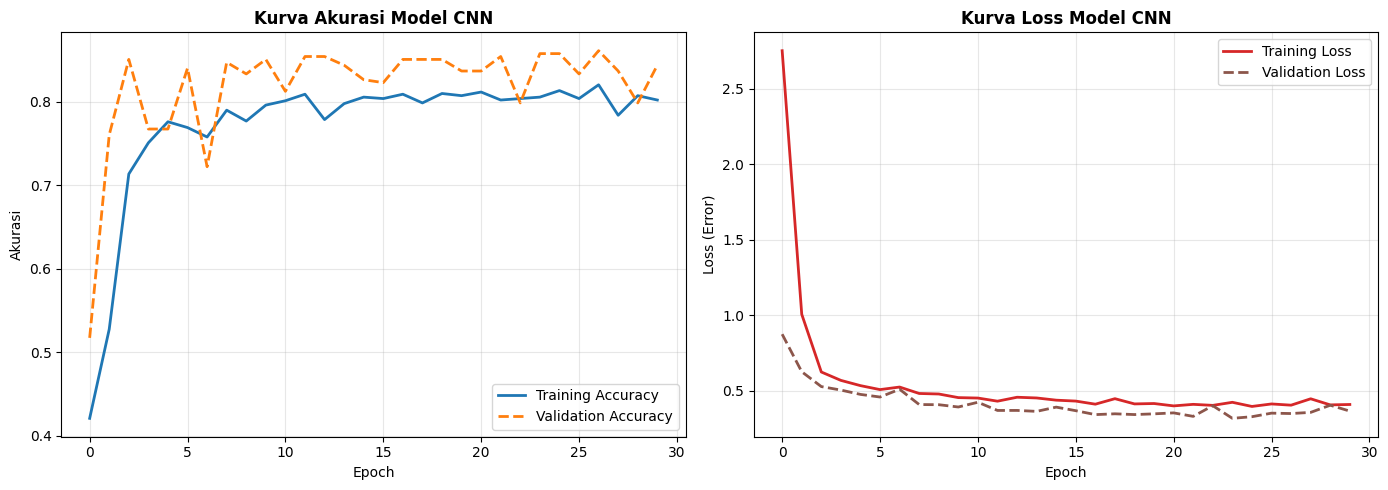

In [ ]:
# =========================================================
# SMART FARMING BAYAM BRAZIL - TRAINING & EVALUATION PHASE
# Kelompok 3 🍃
# =========================================================

import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# 1. MEMBACA DATASET
nama_file = "Data_Kelembapan_Bayam_Brazil_1440.xlsx"

if os.path.exists(nama_file):
    data = pd.read_excel(nama_file)
    print("[INFO] Dataset berhasil dimuat! Menampilkan 5 data teratas:")
    print(data.head())
else:
    raise FileNotFoundError(f"File '{nama_file}' tidak ditemukan. Silahkan upload file tersebut ke tab Files (ikon folder) di sebelah kiri Colab Anda terlebih dahulu.")

# 2. PREPROCESSING DATA
encoder = LabelEncoder()
data['Status_Encode'] = encoder.fit_transform(data['Status Tanah'])

# Fitur input: Kelembapan Tanah dan Suhu Udara
X = data[['Kelembapan Tanah (%)', 'Suhu (°C)']].values
y = data['Status_Encode'].values

# Reshape untuk struktur input CNN (samples, features, channels)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data training dan testing (80% : 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. ARSITEKTUR MODEL CNN
model = Sequential([
    Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(2,1)),
    MaxPooling1D(pool_size=1),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(encoder.classes_), activation='softmax')
])

# 4. COMPILE & TRAIN MODEL
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n--- Memulai Proses Training CNN (30 Epochs) ---")
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# 5. EVALUASI MODEL
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAkurasi Pengujian Model CNN: {accuracy * 100:.2f}%")

# 6. SIMPAN MODEL & ENCODER
model.save("model_cnn_bayam_brazil.h5")
with open("encoder_bayam_brazil.pkl", "wb") as f:
    pickle.dump(encoder, f)
print("[SUKSES] File 'model_cnn_bayam_brazil.h5' & 'encoder_bayam_brazil.pkl' berhasil disimpan.")

# 7. VISUALISASI PERFORMA CNN (KURVA AKURASI & LOSS)
print("\n--- Menampilkan Grafik Analisis Performa Model ---")
plt.figure(figsize=(14, 5))

# Plot Kurva Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Kurva Akurasi Model CNN', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot Kurva Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#d62728', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#8c564b', linestyle='--', linewidth=2)
plt.title('Kurva Loss Model CNN', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (Error)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

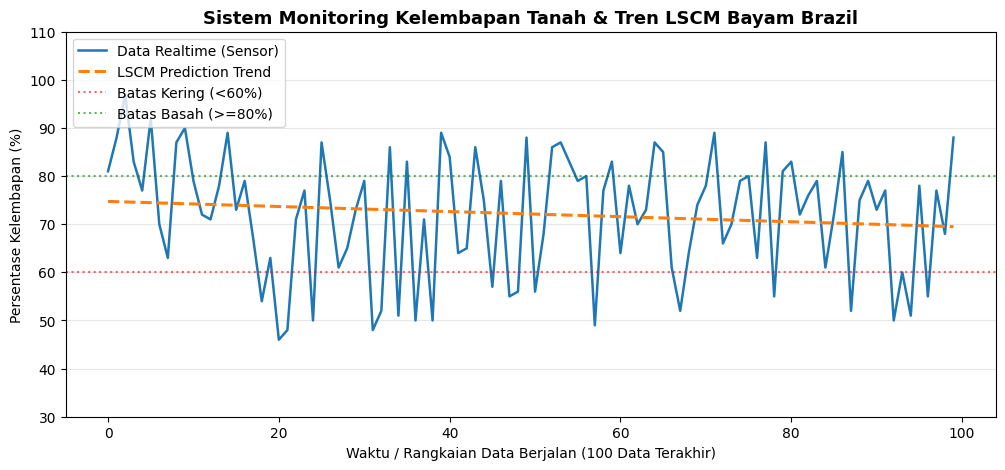

 DATA DASHBOARD MONITORING REALTIME - LOG KE-87
 🟢 BACA SENSOR -> Kelembapan Tanah: 88%  |  Suhu Udara: 27.7°C
 🤖 MODEL CNN   -> Klasifikasi Status Tanah  : Basah
 📈 MODEL LSCM  -> Proyeksi Tren Berikutnya   : 69.50%
 ⚡ AUTOMATION  -> Keputusan Sakelar Pompa    : ❌ POMPA AIR MATI (Tanah Terlalu Basah)
💡 Tips: Klik tanda kotak hitam (Stop/Interrupt) di kiri cell untuk mengakhiri program.

[INFO] Sistem Monitoring Realtime Berhasil Dimatikan Sempurna.


In [ ]:
# =========================================================
# SMART FARMING BAYAM BRAZIL - REALTIME ENGINE & VISUALIZATION
# Kelompok 3 🍃
# =========================================================

import time
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from IPython.display import clear_output

# 1. AMBIL KONFIGURASI MODEL & DATASET HISTORIS
print("Mengintegrasikan Model dan Grafik Ke Dalam Sistem Realtime...")
model_realtime = tf.keras.models.load_model("model_cnn_bayam_brazil.h5")

with open("encoder_bayam_brazil.pkl", "rb") as f:
    encoder_realtime = pickle.load(f)

# Membaca data historis asli sebagai basis awal algoritma LSCM
data_historis = pd.read_excel("Data_Kelembapan_Bayam_Brazil_1440.xlsx")

# Membatasi window awal grafik mengambil 100 data terakhir dari excel agar tidak menumpuk
kelembapan_history = data_historis['Kelembapan Tanah (%)'].iloc[-100:].values.tolist()
lscm_predictions = []

# Menginisialisasi tren regresi LSCM awal
x_init = np.arange(len(kelembapan_history)).reshape(-1, 1)
regresi_init = LinearRegression().fit(x_init, kelembapan_history)
lscm_predictions = regresi_init.predict(x_init).tolist()

# Fungsi Simulasi Data Masuk dari Sensor IoT (DHT11 / Soil Moisture)
def dapatkan_data_sensor_realtime():
    # Simulasi data acak berkisar antara fluktuasi normal kelembapan dan suhu tanaman
    kelembapan_sekarang = np.random.randint(45, 90)
    suhu_sekarang = round(np.random.uniform(25.0, 33.0), 1)
    return kelembapan_sekarang, suhu_sekarang

# 2. EKSEKUSI PEMANTAUAN REALTIME SENSOR
try:
    counter = 1
    while True:
        # Menangkap data sensor baru
        kelembapan, suhu = dapatkan_data_sensor_realtime()

        # Menyisipkan data sensor baru ke riwayat
        kelembapan_history.append(kelembapan)

        # Kalkulasi Ulang Algoritma LSCM (Linear Regression) dengan masuknya data baru
        x = np.arange(len(kelembapan_history)).reshape(-1, 1)
        regresi = LinearRegression()
        regresi.fit(x, kelembapan_history)

        # Generate seluruh garis prediksi tren LSCM untuk plotting grafis
        lscm_predictions = regresi.predict(x).tolist()
        tren_berikutnya = lscm_predictions[-1]

        # Slide Windowing: Pertahankan visualisasi konstan hanya 100 data berjalan terakhir
        if len(kelembapan_history) > 100:
            kelembapan_history.pop(0)
            lscm_predictions.pop(0)

        # Pemrosesan Matriks Klasifikasi CNN
        input_sensor = np.array([[kelembapan, suhu]]).reshape(1, 2, 1)
        prediksi_output = model_realtime.predict(input_sensor, verbose=0)
        kelas_id = np.argmax(prediksi_output)
        status_tanah_cnn = encoder_realtime.inverse_transform([kelas_id])[0]

        # Logika Otomatisasi Sakelar Pompa Air Berdasarkan Parameter Batas Aturan
        if kelembapan < 60:
            status_pompa = "🔥 POMPA AIR MENYALA (Tanah Kering)"
        elif 60 <= kelembapan <= 79:
            status_pompa = "🛑 POMPA AIR MATI (Kondisi Ideal)"
        else:
            status_pompa = "❌ POMPA AIR MATI (Tanah Terlalu Basah)"

        # ---------------------------------------------------
        # RENDERING ANIMASI GRAFIK MONITORING INTERAKTIF
        # ---------------------------------------------------
        clear_output(wait=True) # Membersihkan visualisasi lama agar grafik beranimasi di tempat

        plt.figure(figsize=(12, 5))

        # Plot data kelembapan asli dari sensor
        plt.plot(kelembapan_history, label='Data Realtime (Sensor)', color='#1f77b4', linewidth=1.8)

        # Plot garis prediksi tren LSCM
        plt.plot(lscm_predictions, label='LSCM Prediction Trend', color='#ff7f0e', linestyle='--', linewidth=2.2)

        # Membuat Garis Ambang Batas Kondisi Tanah Sesuai Ketentuan Aturan
        plt.axhline(y=60, color='red', linestyle=':', alpha=0.6, label='Batas Kering (<60%)')
        plt.axhline(y=80, color='green', linestyle=':', alpha=0.6, label='Batas Basah (>=80%)')

        # Atribut Pelengkap Estetika Grafik
        plt.title("Sistem Monitoring Kelembapan Tanah & Tren LSCM Bayam Brazil", fontsize=13, fontweight='bold')
        plt.xlabel("Waktu / Rangkaian Data Berjalan (100 Data Terakhir)", fontsize=10)
        plt.ylabel("Persentase Kelembapan (%)", fontsize=10)
        plt.ylim(30, 110)
        plt.legend(loc='upper left')
        plt.grid(axis='y', alpha=0.3)

        # Tampilkan Grafik ke Layar Colab
        plt.show()

        # Tampilkan Teks Log Keterangan Tepat di Bawah Grafik
        print("="*70)
        print(f" DATA DASHBOARD MONITORING REALTIME - LOG KE-{counter}")
        print("="*70)
        print(f" 🟢 BACA SENSOR -> Kelembapan Tanah: {kelembapan}%  |  Suhu Udara: {suhu}°C")
        print(f" 🤖 MODEL CNN   -> Klasifikasi Status Tanah  : {status_tanah_cnn}")
        print(f" 📈 MODEL LSCM  -> Proyeksi Tren Berikutnya   : {tren_berikutnya:.2f}%")
        print(f" ⚡ AUTOMATION  -> Keputusan Sakelar Pompa    : {status_pompa}")
        print("="*70)
        print("💡 Tips: Klik tanda kotak hitam (Stop/Interrupt) di kiri cell untuk mengakhiri program.")

        # Interval pembacaan (jeda waktu 2 detik per data masuk)
        time.sleep(2)
        counter += 1

except KeyboardInterrupt:
    print("\n[INFO] Sistem Monitoring Realtime Berhasil Dimatikan Sempurna.")

In [ ]:
# =========================================================
# SMART FARMING BAYAM BRAZIL - SUBSISTEM 2: CNN 2D (3 KELAS)
# Kelompok 3 🍃 - Deteksi Panen Berdasarkan Daun & Batang
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. SETUP FOLDER UNTUK 3 PARAMETER KONDISI
print("--- Menyiapkan Folder & Dataset Tiruan 3 Kelas ---")
KATEGORI = ['belum_panen', 'mendekati_panen', 'siap_panen']
for kat in KATEGORI:
    os.makedirs(f'dataset_daun_v2/{kat}', exist_ok=True)

# Generate gambar tiruan untuk merepresentasikan Daun + Batang
for i in range(40):
    # a. Belum Panen (Daun sempit, batang tipis, warna hijau kekuningan/muda)
    img_belum = np.random.randint(110, 190, (150, 150, 3), dtype=np.uint8)
    img_belum[:, :, 0] = np.random.randint(30, 80, (150, 150))   # Red agak tinggi
    img_belum[:, :, 1] = np.random.randint(140, 220, (150, 150)) # Green muda
    plt.imsave(f'dataset_daun_v2/belum_panen/daun_kecil_{i}.jpg', img_belum)

    # b. Mendekati Panen (Daun ukuran sedang, batang mulai kokoh, warna hijau standar)
    img_dekat = np.random.randint(60, 120, (150, 150, 3), dtype=np.uint8)
    img_dekat[:, :, 1] = np.random.randint(100, 160, (150, 150)) # Green sedang
    plt.imsave(f'dataset_daun_v2/mendekati_panen/daun_sedang_{i}.jpg', img_dekat)

    # c. Siap Panen (Daun lebar, batang tebal, warna hijau tua pekat)
    img_siap = np.random.randint(20, 70, (150, 150, 3), dtype=np.uint8)
    img_siap[:, :, 1] = np.random.randint(70, 130, (150, 150))   # Green tua pekat
    plt.imsave(f'dataset_daun_v2/siap_panen/daun_lebar_{i}.jpg', img_siap)

print("[SUKSES] Dataset 3 Kelas berhasil dibuat di folder 'dataset_daun_v2/'!\n")

# 2. PREPROCESSING & DATA AUGMENTATION YANG DIOPTIMASI
# Ditambahkan rotasi dan zoom agar AI pintar mendeteksi "Kepadatan Rimbun" dari berbagai sudut
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,       # Memutar gambar jika foto miring
    zoom_range=0.2,           # Memperbesar/mengecilkan untuk simulasi ukuran koin/lebar daun
    horizontal_flip=True,    # Membalik gambar secara horizontal
    validation_split=0.2      # Split 80% Training, 20% Validasi
)

train_generator = datagen.flow_from_directory(
    'dataset_daun_v2',
    target_size=(150, 150),
    batch_size=8,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    'dataset_daun_v2',
    target_size=(150, 150),
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)
# 3. ARSITEKTUR CNN 2D MULTI-CLASS
model_panen_3kelas = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'), # Menambah layer ekstra untuk fitur batang
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax') # 3 Neuron Output dengan Softmax untuk Probabilitas
])

# 4. COMPILE & TRAINING
model_panen_3kelas.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Memulai Training CNN 2D Mengekstrak Warna, Lebar Daun, & Batang ---")
history = model_panen_3kelas.fit(
    train_generator,
    epochs=12,
    validation_data=val_generator
)

# Simpan Model dan Label Map
model_panen_3kelas.save("model_cnn2d_bayam_3kelas.h5")
label_map = {v: k for k, v in train_generator.class_indices.items()}
with open("label_map_panen.pkl", "wb") as f:
    import pickle
    pickle.dump(label_map, f)

print("\n[SUKSES] Model Multi-Class 'model_cnn2d_bayam_3kelas.h5' berhasil disimpan!")

--- Menyiapkan Folder & Dataset Tiruan 3 Kelas ---
[SUKSES] Dataset 3 Kelas berhasil dibuat di folder 'dataset_daun_v2/'!

Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.

--- Memulai Training CNN 2D Mengekstrak Warna, Lebar Daun, & Batang ---
Epoch 1/12


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 367ms/step - accuracy: 0.6146 - loss: 0.7855 - val_accuracy: 0.6667 - val_loss: 0.3431
Epoch 2/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 292ms/step - accuracy: 0.9167 - loss: 0.1657 - val_accuracy: 1.0000 - val_loss: 0.0061
Epoch 3/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 5.5951e-05
Epoch 4/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 1.0000 - loss: 7.2865e-05 - val_accuracy: 1.0000 - val_loss: 8.2800e-06
Epoch 5/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - accuracy: 1.0000 - loss: 1.5989e-05 - val_accuracy: 1.0000 - val_loss: 5.6525e-06
Epoch 6/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 1.0000 - loss: 4.5343e-05 - val_accuracy: 1.0000 - val_loss: 1.4206e-06
Epoch 7/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - accuracy: 1.0000 - loss: 8.0245e-06 - val_accuracy: 1.0000 - val_loss: 8.6923e-07
Epoch 8/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 290ms/step - accuracy: 1.0000 - loss: 


[SUKSES] Model Multi-Class 'model_cnn2d_bayam_3kelas.h5' berhasil disimpan!


[INFO] Model CNN 2D dan Label Map berhasil diintegrasikan!


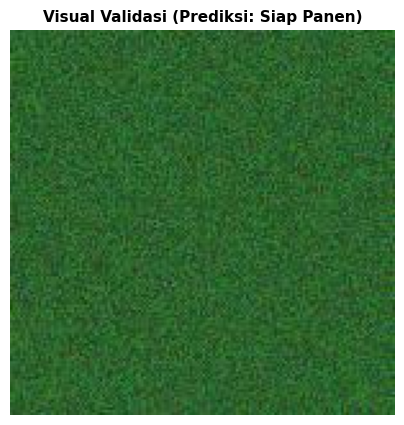

        HASIL EKSTRAKSI GEOMETRI & WARNA TANAMAN (CNN 2D)       
 HASIL DETEKSI SISTEM : SIAP_PANEN
 TINGKAT KEYAKINAN AI : 100.00% Confidence Score
-----------------------------------------------------------------
 KESIMPULAN & ANALISIS FITUR KLASIFIKASI:
 🍃 STATUS REKOMENDASI : [ SEGERA LAKUKAN PEMANENAN ]
 📌 Indikator Daun     : Daun bagian atas sudah MELEBAR (minimal selebar jempol/koin).
 📌 Indikator Warna    : Hijau segar pekat dan tekstur daun tebal/renyah.
 📌 Indikator Rimbun   : Kondisi rimbun penuh, lebat, dan saling menutupi pot.
                         (Aman dipotong, tanaman tidak akan gundul).


In [ ]:
# =========================================================
# SMART FARMING BAYAM BRAZIL - INFERENCE TEST 3 PARAMETER
# Kelompok 3 🍃 - Deteksi Berdasarkan Kriteria Daun & Kepadatan
# =========================================================

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# 1. MEMUAT MODEL DAN LABEL MAP YANG SUDAH DILATIH
MODEL_PATH = "model_cnn2d_bayam_3kelas.h5"
LABEL_PATH = "label_map_panen.pkl"

if os.path.exists(MODEL_PATH) and os.path.exists(LABEL_PATH):
    model_pakar = tf.keras.models.load_model(MODEL_PATH)
    with open(LABEL_PATH, "rb") as f:
        label_map = pickle.load(f)
    print("[INFO] Model CNN 2D dan Label Map berhasil diintegrasikan!")
else:
    print("[ERROR] File model atau label map tidak ditemukan. Pastikan Anda sudah menjalankan Cell 4.")

# 2. FUNGSI UTAMA ANALISIS CITRA (COMPUTER VISION)
def analisis_pemanenan_bayam(path_foto_daun):
    """
    Fungsi untuk memprediksi kesiapan panen Bayam Brazil
    berdasarkan visual warna, lebar daun, dan kepadatan rimbun.
    """
    if not os.path.exists(path_foto_daun):
        print(f"[ERROR] File foto '{path_foto_daun}' tidak ditemukan di direktori Colab.")
        return

    # Preprocessing citra input agar sesuai dengan format training CNN (150x150)
    img = image.load_img(path_foto_daun, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0 # Normalisasi skala piksel

    # Eksekusi Prediksi Menggunakan Lapisan Softmax CNN 2D
    prediksi_matriks = model_pakar.predict(img_array, verbose=0)[0]
    indeks_tertinggi = np.argmax(prediksi_matriks)
    status_terpilih = label_map[indeks_tertinggi]
    persentase_yakin = prediksi_matriks[indeks_tertinggi] * 100

    # Tampilkan Foto Tanaman yang Diuji
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Visual Validasi (Prediksi: {status_terpilih.replace('_', ' ').title()})", fontsize=11, fontweight='bold')
    plt.axis('off')
    plt.show()

    # 3. OUTPUT LOGIKA KEPUTUSAN BERDASARKAN INDIKATOR FISIK BOTANI
    print("="*65)
    print("        HASIL EKSTRAKSI GEOMETRI & WARNA TANAMAN (CNN 2D)       ")
    print("="*65)
    print(f" HASIL DETEKSI SISTEM : {status_terpilih.upper()}")
    print(f" TINGKAT KEYAKINAN AI : {persentase_yakin:.2f}% Confidence Score")
    print("-"*65)
    print(" KESIMPULAN & ANALISIS FITUR KLASIFIKASI:")

    if status_terpilih == 'belum_panen':
        print(" ❌ STATUS REKOMENDASI : [ JANGAN DIPANEN ]")
        print(" 📌 Indikator Daun     : Daun di bagian atas masih menguncup kecil / sempit.")
        print(" 📌 Indikator Warna    : Dominan hijau sangat muda transparan.")
        print(" 📌 Indikator Rimbun   : Tanaman masih renggang, belum penuh dalam pot.")

    elif status_terpilih == 'mendekati_panen':
        print(" ⏳ STATUS REKOMENDASI : [ MONITORING BERKALA / 1-2 MINGGU LAGI ]")
        print(" 📌 Indikator Daun     : Ukuran lebar daun mulai berkembang ke ukuran sedang.")
        print(" 📌 Indikator Warna    : Gradasi hijau mulai normal (menuju hijau segar).")
        print(" 📌 Indikator Rimbun   : Cabang samping mulai tumbuh aktif mengisi ruang pot.")

    elif status_terpilih == 'siap_panen':
        print(" 🍃 STATUS REKOMENDASI : [ SEGERA LAKUKAN PEMANENAN ]")
        print(" 📌 Indikator Daun     : Daun bagian atas sudah MELEBAR (minimal selebar jempol/koin).")
        print(" 📌 Indikator Warna    : Hijau segar pekat dan tekstur daun tebal/renyah.")
        print(" 📌 Indikator Rimbun   : Kondisi rimbun penuh, lebat, dan saling menutupi pot.")
        print("                         (Aman dipotong, tanaman tidak akan gundul).")

    print("="*65)

# =========================================================
# 4. SIMULASI JALANKAN PENGUJIAN FOTO
# =========================================================
# Untuk keperluan demo, kita panggil salah satu gambar tiruan dari folder 'mendekati_panen'.
# TIPS: Jika ingin menguji dengan foto asli Anda, silakan unggah foto ke menu Files di kiri,
# lalu ubah tulisan di dalam tanda petik di bawah ini dengan nama file foto Anda (misal: "bayam_ku.jpg")

contoh_file_tes = "dataset_daun_v2/siap_panen/daun_lebar_14.jpg"
analisis_pemanenan_bayam(contoh_file_tes)